In [70]:
# Import depedencies
from datetime import datetime
from PIL import Image, ImageDraw
import os
import glob
import pandas as pd
from IPython.display import display
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

pd.set_option('display.max_columns', None)

# Google Screenshot to Analyze
## Path to a google screenshot image in your file explorer

In [66]:
source_folder = r"C:\Users\dane.rini\Global Infrastructure\SSC PANYNJ Team - Documents\01 - PANYNJ\10 - Google Screenshot\01 - All Inbound Google Screenshots\Port Liberty New Jersey\09_18_2026"
image_file = 'Port Liberty New Jersey_2026-09-18_1221.png'

image_path = source_folder + "\\" + image_file
image_path

'C:\\Users\\dane.rini\\Global Infrastructure\\SSC PANYNJ Team - Documents\\01 - PANYNJ\\10 - Google Screenshot\\01 - All Inbound Google Screenshots\\Port Liberty New Jersey\\09_18_2026\\Port Liberty New Jersey_2026-09-18_1221.png'

# ROI Selection tool
## Function to draw analysis polygons on your study image

In [67]:
polygon_points = []
polygon_closed = False

rectangle_start = None
rectangle_end = None
drawing_rectangle = False

panning = False
pan_start_mouse = None
pan_start_view = None

mode = 'polygon'  # 'polygon' or 'rectangle'

img = None

# Zoom / view state
zoom = 1.0
min_zoom = 0.2
max_zoom = 12.0
zoom_step = 1.2

view_x = 0  # top-left x of visible area in SCALED image coords
view_y = 0  # top-left y of visible area in SCALED image coords

window_name = "Image"
window_w = None
window_h = None


# ----------------------------
# Helpers
# ----------------------------
def clamp_view():
    """Keep the viewport within the bounds of the scaled image."""
    global view_x, view_y, zoom, img, window_w, window_h

    scaled_w = max(1, int(img.shape[1] * zoom))
    scaled_h = max(1, int(img.shape[0] * zoom))

    max_x = max(0, scaled_w - window_w)
    max_y = max(0, scaled_h - window_h)

    view_x = max(0, min(view_x, max_x))
    view_y = max(0, min(view_y, max_y))


def screen_to_image(x, y):
    """
    Convert display-window coords to ORIGINAL image coords.
    """
    img_x = int((view_x + x) / zoom)
    img_y = int((view_y + y) / zoom)

    img_x = max(0, min(img_x, img.shape[1] - 1))
    img_y = max(0, min(img_y, img.shape[0] - 1))
    return img_x, img_y


def zoom_at(x, y, factor):
    """
    Zoom centered on the mouse position, preserving the image point under the cursor.
    x, y are window/display coords.
    """
    global zoom, view_x, view_y

    old_zoom = zoom
    new_zoom = max(min_zoom, min(max_zoom, zoom * factor))

    if abs(new_zoom - old_zoom) < 1e-9:
        return

    # Original image coords under cursor before zoom
    img_x = (view_x + x) / old_zoom
    img_y = (view_y + y) / old_zoom

    zoom = new_zoom

    # Keep same image point under cursor after zoom
    view_x = int(img_x * zoom - x)
    view_y = int(img_y * zoom - y)

    clamp_view()


def reset_view():
    global zoom, view_x, view_y
    zoom = 1.0
    view_x = 0
    view_y = 0
    clamp_view()


def clear_current_selection():
    global polygon_points, polygon_closed
    global rectangle_start, rectangle_end, drawing_rectangle

    polygon_points = []
    polygon_closed = False
    rectangle_start = None
    rectangle_end = None
    drawing_rectangle = False


def get_display_image():
    """
    Build the displayed image by:
    1) scaling the base image
    2) drawing overlays in scaled coords
    3) cropping to the viewport
    """
    global img, zoom, view_x, view_y, window_w, window_h
    global polygon_points, polygon_closed
    global rectangle_start, rectangle_end

    scaled_w = max(1, int(img.shape[1] * zoom))
    scaled_h = max(1, int(img.shape[0] * zoom))
    scaled = cv2.resize(img, (scaled_w, scaled_h), interpolation=cv2.INTER_LINEAR)

    # Draw polygon
    if polygon_points:
        scaled_pts = [(int(px * zoom), int(py * zoom)) for px, py in polygon_points]

        for pt in scaled_pts:
            cv2.circle(scaled, pt, 5, (0, 0, 0), -1)

        for i in range(1, len(scaled_pts)):
            cv2.line(scaled, scaled_pts[i - 1], scaled_pts[i], (0, 0, 255), 2)

        if polygon_closed and len(scaled_pts) > 2:
            cv2.line(scaled, scaled_pts[-1], scaled_pts[0], (0, 0, 255), 2)

    # Draw rectangle
    if rectangle_start and rectangle_end:
        p1 = (int(rectangle_start[0] * zoom), int(rectangle_start[1] * zoom))
        p2 = (int(rectangle_end[0] * zoom), int(rectangle_end[1] * zoom))
        cv2.rectangle(scaled, p1, p2, (255, 0, 0), 2)

    clamp_view()

    # Crop viewport
    x1 = view_x
    y1 = view_y
    x2 = min(view_x + window_w, scaled_w)
    y2 = min(view_y + window_h, scaled_h)

    cropped = scaled[y1:y2, x1:x2].copy()

    # Pad if needed (when image smaller than window)
    if cropped.shape[1] < window_w or cropped.shape[0] < window_h:
        canvas = np.full((window_h, window_w, 3), 220, dtype=np.uint8)
        canvas[:cropped.shape[0], :cropped.shape[1]] = cropped
        cropped = canvas

    # Status text
    status = f"Mode: {mode} | Zoom: {zoom:.2f}x | View: ({view_x}, {view_y})"
    cv2.putText(
        cropped,
        status,
        (10, 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (20, 20, 20),
        2,
        cv2.LINE_AA
    )

    return cropped


# ----------------------------
# Mouse callback
# ----------------------------
def draw_polygon(event, x, y, flags, param):
    global polygon_points, polygon_closed
    global rectangle_start, rectangle_end, drawing_rectangle
    global panning, pan_start_mouse, pan_start_view
    global mode, view_x, view_y

    # Mouse wheel zoom
    if event == cv2.EVENT_MOUSEWHEEL:
        # Fallback for OpenCV builds that do not have cv2.getMouseWheelDelta()
        wheel_delta = flags >> 16

        # convert to signed 16-bit integer
        if wheel_delta > 32767:
            wheel_delta -= 65536

        if wheel_delta > 0:
            zoom_at(x, y, zoom_step)
        elif wheel_delta < 0:
            zoom_at(x, y, 1 / zoom_step)
        return

    # Middle mouse starts pan
    if event == cv2.EVENT_MBUTTONDOWN:
        panning = True
        pan_start_mouse = (x, y)
        pan_start_view = (view_x, view_y)
        return

    elif event == cv2.EVENT_MOUSEMOVE and panning:
        dx = x - pan_start_mouse[0]
        dy = y - pan_start_mouse[1]

        view_x = pan_start_view[0] - dx
        view_y = pan_start_view[1] - dy
        clamp_view()
        return

    elif event == cv2.EVENT_MBUTTONUP:
        panning = False
        return

    # Ignore drawing clicks while panning
    if panning:
        return

    img_x, img_y = screen_to_image(x, y)

    if mode == 'polygon':
        if event == cv2.EVENT_LBUTTONDOWN:
            if polygon_closed:
                print("Polygon already closed. Press [c] to clear and start again.")
                return

            polygon_points.append((img_x, img_y))
            print(f"Added point: {(img_x, img_y)}")

        elif event == cv2.EVENT_RBUTTONDOWN:
            if len(polygon_points) > 2:
                polygon_closed = True
                print(f"Polygon closed with {len(polygon_points)} points.")
            else:
                print("Need at least 3 points to close polygon.")

    elif mode == 'rectangle':
        if event == cv2.EVENT_LBUTTONDOWN:
            rectangle_start = (img_x, img_y)
            rectangle_end = (img_x, img_y)
            drawing_rectangle = True

        elif event == cv2.EVENT_MOUSEMOVE and drawing_rectangle:
            rectangle_end = (img_x, img_y)

        elif event == cv2.EVENT_LBUTTONUP:
            if drawing_rectangle:
                rectangle_end = (img_x, img_y)
                drawing_rectangle = False
                print(f"Rectangle drawn: {rectangle_start} to {rectangle_end}")



# Draw your ROI

In [69]:
# Controls:
  # [p] - Polygon Mode
  # [r] - Rectangle Mode
  # [c] - Clear current selection
  # [f] - Reset zoom/pan
  # [+] - Zoom in
  # [-] - Zoom out
  # [q] - Quit

In [68]:
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

# Window size: fit within a reasonable screen region
max_w = 1400
max_h = 900
window_w = min(img.shape[1], max_w)
window_h = min(img.shape[0], max_h)

cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.resizeWindow(window_name, window_w, window_h)
cv2.setMouseCallback(window_name, draw_polygon)

print("Controls:")
print("  [p] - Polygon Mode")
print("  [r] - Rectangle Mode")
print("  [c] - Clear current selection")
print("  [f] - Reset zoom/pan")
print("  [+] - Zoom in")
print("  [-] - Zoom out")
print("  [q] - Quit")
print("")
print("Mouse:")
print("  Left-click      -> add polygon point / start rectangle")
print("  Right-click     -> close polygon")
print("  Mouse wheel     -> zoom in/out")
print("  Middle-drag     -> pan")

while True:
    display = get_display_image()
    cv2.imshow(window_name, display)

    key = cv2.waitKey(20) & 0xFF

    if key == ord('q'):
        break

    elif key == ord('p'):
        mode = 'polygon'
        clear_current_selection()
        print("Switched to Polygon mode.")

    elif key == ord('r'):
        mode = 'rectangle'
        clear_current_selection()
        print("Switched to Rectangle mode.")

    elif key == ord('c'):
        clear_current_selection()
        print("Cleared current selection.")

    elif key == ord('f'):
        reset_view()
        print("Reset zoom/pan.")

    elif key in (ord('+'), ord('=')):
        zoom_at(window_w // 2, window_h // 2, zoom_step)

    elif key in (ord('-'), ord('_')):
        zoom_at(window_w // 2, window_h // 2, 1 / zoom_step)

cv2.destroyAllWindows()

if mode == 'polygon' and polygon_points:
    print(f"Final polygon points: {polygon_points}")
elif mode == 'rectangle' and rectangle_start and rectangle_end:
    print(f"Final rectangle: {rectangle_start} to {rectangle_end}")
else:
    print("No region selected.")

Controls:
  [p] - Polygon Mode
  [r] - Rectangle Mode
  [c] - Clear current selection
  [f] - Reset zoom/pan
  [+] - Zoom in
  [-] - Zoom out
  [q] - Quit

Mouse:
  Left-click      -> add polygon point / start rectangle
  Right-click     -> close polygon
  Mouse wheel     -> zoom in/out
  Middle-drag     -> pan
No region selected.


## ROI coordinates output from the above tool are to be copied into the workbook config

In [41]:
# Define multiple workbooks with their own folders + ROI mappings
workbooks_config = {
    r"Port Jersey Blvd": {
        "folder_path": source_folder,
        "roi_mapping": {
            "zone_1": [(1408, 616), (1373, 595), (1369, 603), (1400, 624)],
            "zone_2": [(1266, 530), (1208, 497), (1186, 489), (1178, 497), (1259, 538)],
            "zone_3": [(1176, 483), (1100, 455), (1047, 446), (1006, 444), (951, 449), (957, 459), (1036, 461), (1087, 462), (1102, 467), (1168, 491)],
            "zone_4": [(820, 451), (758, 443), (756, 457), (819, 466)],
            "zone_5": [(636, 396), (583, 358), (574, 368), (629, 406)],
        },
    }
}

# Check ROI Selections
## Confirm ROI polygons cover the area you intended

In [57]:
def show_rois_on_image(image_path, roi_mapping, linewidth=2, alpha=0.75, show_labels=True):
    # 1) 读图
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)

    # 2) 准备画布
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img_np)
    ax.set_axis_off()

    # 3) 给每个ROI分配一个颜色（用 colormap 自动生成很多不同颜色）
    cmap = plt.get_cmap("tab20")  # 20种颜色，ROI多也够用（超20会循环）
    roi_names = list(roi_mapping.keys())

    for i, roi_name in enumerate(roi_names):
        roi = roi_mapping[roi_name]
        # color = cmap(i % 20)
        color = 'magenta'

        if roi is None:
            continue

        # ROI是多边形点列表：[(x,y), (x,y), ...]
        if isinstance(roi, list):
            poly = Polygon(roi, closed=True, fill=True,
                           edgecolor='black', facecolor=color,
                           linewidth=linewidth, alpha=alpha)
            ax.add_patch(poly)

            # 标签放在多边形“中心”（简单取平均）
            if show_labels:
                xs = [p[0] for p in roi]
                ys = [p[1] for p in roi]
                cx, cy = sum(xs)/len(xs), sum(ys)/len(ys)
                ax.text(cx, cy, roi_name, color="white",
                        fontsize=10, ha="center", va="center",
                        bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.25))

        # ROI是矩形：(left, upper, right, lower)
        elif isinstance(roi, tuple) and len(roi) == 4:
            l, u, r, b = roi
            rect_pts = [(l, u), (r, u), (r, b), (l, b)]
            poly = Polygon(rect_pts, closed=True, fill=True,
                           edgecolor=color, facecolor=color,
                           linewidth=linewidth, alpha=alpha)
            ax.add_patch(poly)

            if show_labels:
                ax.text((l+r)/2, (u+b)/2, roi_name, color="white",
                        fontsize=10, ha="center", va="center",
                        bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.6))

    plt.tight_layout()
    plt.show()

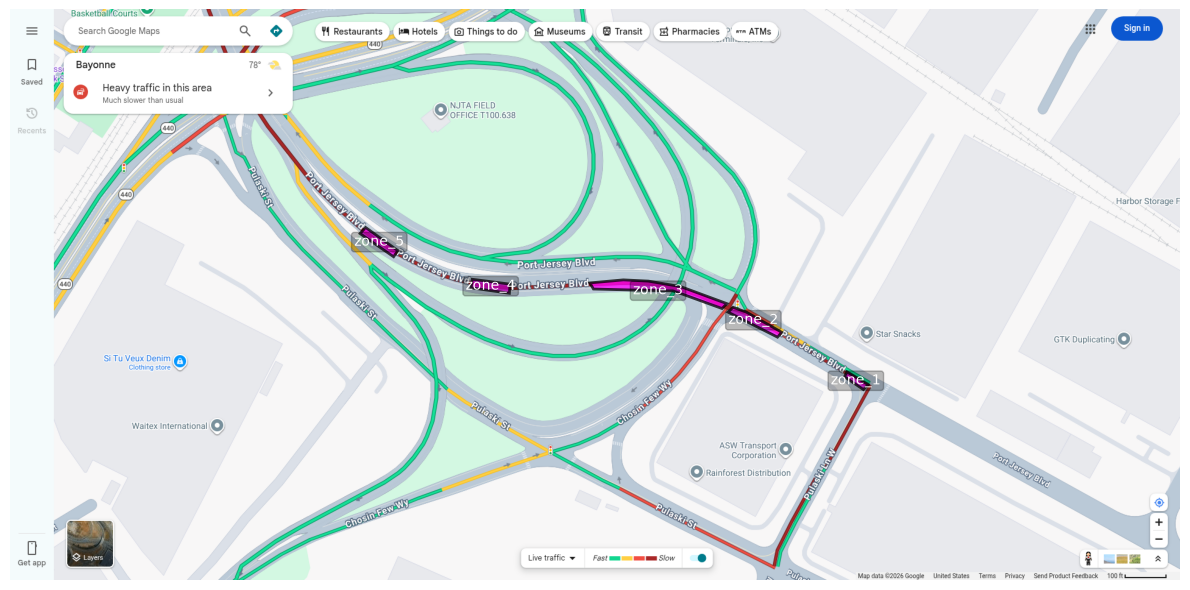

In [65]:
show_rois_on_image(
    image_path=image_path,
    roi_mapping=workbooks_config[r"Port Jersey Blvd"]["roi_mapping"],
    # show_labels=False
)

# Pixel Counter

In [46]:
# Constants
TARGET_COLORS = [(252, 205, 73), (22, 224, 152), (205, 98, 68), (183, 52, 55)]

# Corresponding normalized colors mapped to traffic labels (only the main traffic colors)
COLOR_LABELS = {
    (22/255, 224/255, 152/255): 'Light Traffic',
    (252/255, 205/255, 73/255): 'Moderate Traffic',
    (205/255, 98/255, 68/255): 'Heavy Traffic',
    (183/255, 52/255, 55/255): 'Severe Traffic'
}

# --- Utility Functions ---
def extract_date_and_time_from_filename(file_path):
    try:
        file_name = os.path.basename(file_path)
        name_without_ext = os.path.splitext(file_name)[0]
        file_name_parts = name_without_ext.split('_')
        date_time_str = file_name_parts[-2] + '_' + file_name_parts[-1]
        return datetime.strptime(date_time_str, '%Y-%m-%d_%H%M')
    except Exception as e:
        print(f"[ERROR] Filename parsing failed for {file_path}: {e}")
        return None


def count_rgb_colors(image_path, roi=None, show_images=False):
    image = Image.open(image_path).convert('RGB')

    if show_images:
        print('Original Image:')
        display(image)

    if isinstance(roi, tuple):  # Rectangular crop
        image = image.crop(roi)

    elif isinstance(roi, list):  # Polygonal ROI
        # Compute bounding box
        xs, ys = zip(*roi)
        bbox = (min(xs), min(ys), max(xs), max(ys))

        # Crop image to polygon bounding box
        cropped_image = image.crop(bbox)

        # Offset polygon points to cropped box coordinates
        offset_polygon = [(x - bbox[0], y - bbox[1]) for x, y in roi]

        # Create a new mask for the cropped image
        mask = Image.new("L", cropped_image.size, 0)
        ImageDraw.Draw(mask).polygon(offset_polygon, fill=255)

        # Apply mask to cropped image
        image = Image.new("RGB", cropped_image.size)
        image.paste(cropped_image, mask=mask)

    if show_images:
        print("Cropped Images (ROI):")
        display(image)

    palette_colors = [
        (252, 205, 73),   # Warm Yellow / Moderate Traffic
        (22, 224, 152),   # Bright Turquoise / Light Traffic
        (183, 52, 55),    # Dark Red / Severe Traffic
        (205, 98, 68),    # Rusty Orange / Heavy Traffic
        (144, 218, 238),  # Light Sky Blue / Background/Water
        (245, 243, 243),  # Very Light Gray / Background/Neutral
        (195, 241, 213),  # Pale Mint Green / Vegetation/Calm Area
        (248, 240, 222),  # Light Beige / Background/Road
        (123, 142, 154),  # Grayish Blue / Infrastructure/Shadows
        (108, 163, 189),  # Soft Medium Blue / Water/Neutral
        (83, 88, 103)]     # Dark Grayish Blue / Road Markings/Shaded

    palette_image = Image.new('P', (1, 1))
    palette_image.putpalette([c for color in palette_colors for c in color])
    posterized_image = image.quantize(palette=palette_image).convert('RGB')

    if show_images:
        print('Posterized Image:')
        display(posterized_image)

    pixels = list(posterized_image.getdata())
    rgb_counts = {}
    for pixel in pixels:
        rgb_counts[pixel[:3]] = rgb_counts.get(pixel[:3], 0) + 1

    filtered_counts = {
        tuple([r / 255, g / 255, b / 255]): rgb_counts.get((r, g, b), 0)
        for r, g, b in TARGET_COLORS
    }

    return filtered_counts, os.path.splitext(os.path.basename(image_path))[0]

def analyze_images_by_roi(folder_path, roi_mapping, show_images=False, image_files=None):
    if roi_mapping is None:
        roi_mapping = {"FullImage": None}

    if image_files is None:
        image_files = glob.glob(os.path.join(folder_path, '**', '*.png'), recursive=True)
    else:
        image_files = [os.path.join(folder_path, f) for f in image_files]

    combined_df = None

    for roi_name, roi_coords in roi_mapping.items():
        print(f"\nProcessing ROI: {roi_name} -> {roi_coords}")
        result_dict = {}

        # Process each image
        for image_path in image_files:
            print(image_path)
            try:
                counts, _ = count_rgb_colors(image_path, roi=roi_coords, show_images=show_images)
            except Exception as e:
                print(f"[WARNING] Skipping corrupted or unreadable image: {image_path} -> {e}")
                continue  # Skip this image
                
            date = extract_date_and_time_from_filename(image_path)
            if date:
                result_dict[date] = counts

        sorted_result_dict = dict(sorted(result_dict.items()))
        dates = list(sorted_result_dict.keys())

        # Prepare color counts by label
        all_colors = COLOR_LABELS.keys()
        color_counts = {color: [] for color in all_colors}
        for date_dict in sorted_result_dict.values():
            for color in all_colors:
                color_counts[color].append(date_dict.get(color, 0))

        # Rename keys to labels, add zone prefix
        labeled_counts = {
            f"{roi_name} {COLOR_LABELS[color]}": counts
            for color, counts in color_counts.items()
            if color in COLOR_LABELS
        }

        # Create dataframe for this zone
        df_zone = pd.DataFrame({'Dates': dates})
        for label, values in labeled_counts.items():
            df_zone[label] = values
        df_zone['Dates'] = pd.to_datetime(df_zone['Dates'])

        # Merge with combined df
        if combined_df is None:
            combined_df = df_zone
        else:
            combined_df = pd.merge(combined_df, df_zone, on="Dates", how="outer")

    return combined_df


In [53]:
for setting_name, config in workbooks_config.items():
        print(f"\n📊 Processing routes for: {setting_name}")
        df = analyze_images_by_roi(
            folder_path=config["folder_path"],
            roi_mapping=config["roi_mapping"],
            image_files=[os.path.basename(image_path)]
        )


📊 Processing routes for: Port Jersey Blvd

Processing ROI: zone_1 -> [(1408, 616), (1373, 595), (1369, 603), (1400, 624)]
C:\Users\dane.rini\Global Infrastructure\SSC PANYNJ Team - Documents\01 - PANYNJ\10 - Google Screenshot\01 - All Inbound Google Screenshots\Port Liberty New Jersey\09_18_2026\Port Liberty New Jersey_2026-09-18_1221.png

Processing ROI: zone_2 -> [(1266, 530), (1208, 497), (1186, 489), (1178, 497), (1259, 538)]
C:\Users\dane.rini\Global Infrastructure\SSC PANYNJ Team - Documents\01 - PANYNJ\10 - Google Screenshot\01 - All Inbound Google Screenshots\Port Liberty New Jersey\09_18_2026\Port Liberty New Jersey_2026-09-18_1221.png

Processing ROI: zone_3 -> [(1176, 483), (1100, 455), (1047, 446), (1006, 444), (951, 449), (957, 459), (1036, 461), (1087, 462), (1102, 467), (1168, 491)]
C:\Users\dane.rini\Global Infrastructure\SSC PANYNJ Team - Documents\01 - PANYNJ\10 - Google Screenshot\01 - All Inbound Google Screenshots\Port Liberty New Jersey\09_18_2026\Port Liberty Ne

C:\Users\dane.rini\AppData\Local\Temp\ipykernel_11868\3701183814.py:79: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixels = list(posterized_image.getdata())
C:\Users\dane.rini\AppData\Local\Temp\ipykernel_11868\3701183814.py:79: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixels = list(posterized_image.getdata())
C:\Users\dane.rini\AppData\Local\Temp\ipykernel_11868\3701183814.py:79: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixels = list(posterized_image.getdata())
C:\Users\dane.rini\AppData\Local\Temp\ipykernel_11868\3701183814.py:79: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixels = list(posterized_image.getdata())
C:\U

In [54]:
df

,Dates,zone_1 Light Traffic,zone_1 Moderate Traffic,zone_1 Heavy Traffic,zone_1 Severe Traffic,zone_2 Light Traffic,zone_2 Moderate Traffic,zone_2 Heavy Traffic,zone_2 Severe Traffic,zone_3 Light Traffic,zone_3 Moderate Traffic,zone_3 Heavy Traffic,zone_3 Severe Traffic,zone_4 Light Traffic,zone_4 Moderate Traffic,zone_4 Heavy Traffic,zone_4 Severe Traffic,zone_5 Light Traffic,zone_5 Moderate Traffic,zone_5 Heavy Traffic,zone_5 Severe Traffic
0,2026-09-18 12:21:00,0,0,2,133,0,0,168,274,12,0,27,1046,0,0,10,305,0,0,4,335
